# N-shift speed benchmark analysis

Confronto delle metriche per diversi valori di `N` (batch size), usando i file prodotti da `tests/Nshift_speed/run_nshift_speed.py`.

In [1]:
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
online2_dir = next((p for p in candidates if (p / "tests" / "Nshift_speed").exists()), None)
if online2_dir is None:
    raise FileNotFoundError("Cannot locate online2 root (missing tests/Nshift_speed).")

benchmark_dir = online2_dir / "tests" / "Nshift_speed"
output_dir = benchmark_dir / "output"
config_path = benchmark_dir / "config.json"

if not config_path.exists():
    raise FileNotFoundError(f"Missing benchmark config: {config_path}")

import json
config_data = json.loads(config_path.read_text(encoding="utf-8"))
scenario_path = benchmark_dir / config_data["scenario_path"]
if not scenario_path.exists():
    raise FileNotFoundError(f"Missing scenario file: {scenario_path}")
scenario = json.loads(scenario_path.read_text(encoding="utf-8"))

summary_path = output_dir / "summary_by_n.csv"
if not summary_path.exists():
    raise FileNotFoundError(f"Missing benchmark summary file: {summary_path}")

print(f"online2_dir:  {online2_dir}")
print(f"benchmark_dir:{benchmark_dir}")
print(f"output_dir:   {output_dir}")
print(f"scenario:     {scenario_path}")

online2_dir:  /home/francis/unipi/carbonshift/carbonshift/online2
benchmark_dir:/home/francis/unipi/carbonshift/carbonshift/online2/tests/Nshift_speed
output_dir:   /home/francis/unipi/carbonshift/carbonshift/online2/tests/Nshift_speed/output
scenario:     /home/francis/unipi/carbonshift/carbonshift/online2/tests/Nshift_speed/scenario_seed_2026.json


In [3]:
summary_df = pd.read_csv(summary_path).sort_values("batch_size").reset_index(drop=True)
summary_df["batch_size"] = summary_df["batch_size"].astype(int)

per_request_by_n = {}
per_timeslot_by_n = {}
batch_timings_by_n = {}

for n in summary_df["batch_size"].tolist():
    run_dir = output_dir / f"N{n}"
    per_request_by_n[n] = pd.read_csv(run_dir / "per_request.csv")
    per_timeslot_by_n[n] = pd.read_csv(run_dir / "per_timeslot.csv")
    batch_timings_by_n[n] = pd.read_csv(run_dir / "batch_timings.csv")

threshold = float(scenario["metadata"]["max_error_threshold"])
total_slots = int(scenario["metadata"]["total_slots"])
slot_duration = float(scenario["metadata"]["slot_duration_seconds"])

summary_df

,batch_size,requests_total,requests_scheduled,requests_unscheduled,batches_executed,total_carbon_cost,global_average_error,solver_time_ms_min,solver_time_ms_max,solver_time_ms_avg,queue_wait_seconds_min,queue_wait_seconds_max,queue_wait_seconds_avg,final_wait_seconds_min,final_wait_seconds_max,final_wait_seconds_avg
0,1,207,207,0,207,5.363953e+06,3.971014,0.361379,1.625316,0.685860,0.0,0.0,0.000000,0.000361,80.000744,26.232570
1,2,207,207,0,104,5.002956e+06,4.067633,0.455600,4.208626,1.304764,0.0,10.0,0.531401,0.000456,80.002484,26.233191
2,3,207,207,0,69,6.224790e+06,4.086957,0.828012,36.020027,8.865076,0.0,10.0,1.256039,0.000828,80.036020,27.206933
3,4,207,207,0,52,5.026858e+06,4.123188,0.979245,261.006432,67.881216,0.0,10.0,1.594203,0.000979,80.122867,26.493325
4,5,207,207,0,42,7.157445e+06,4.021739,1.184777,118.568523,59.086192,0.0,10.0,2.125604,0.001185,80.113944,27.016446
5,6,207,207,0,35,6.250657e+06,3.922705,1.069834,195.683619,94.678099,0.0,10.0,2.560386,0.001070,80.165228,27.680576
6,8,207,207,0,26,6.834566e+06,3.821256,1.704099,325.788430,163.712426,0.0,10.0,4.299517,0.001704,80.325788,27.604109
7,10,207,207,0,21,7.487508e+06,3.792271,1.769645,407.631606,228.668302,0.0,20.0,4.782609,0.001770,80.329931,28.154662


## 1) Configurazione del test

In [4]:
pd.DataFrame(
    {
        "parameter": [
            "seed",
            "total_slots",
            "slot_duration_seconds",
            "requests_per_slot",
            "request_rate_std_factor",
            "deadline_min_slack",
            "deadline_max_slack",
            "error_window_past",
            "error_window_future",
            "max_error_threshold",
            "batch_sizes",
        ],
        "value": [
            scenario["metadata"]["seed"],
            scenario["metadata"]["total_slots"],
            scenario["metadata"]["slot_duration_seconds"],
            scenario["metadata"]["requests_per_slot"],
            scenario["metadata"]["request_rate_std_factor"],
            scenario["metadata"]["deadline_min_slack"],
            scenario["metadata"]["deadline_max_slack"],
            scenario["metadata"]["error_window_past"],
            scenario["metadata"]["error_window_future"],
            scenario["metadata"]["max_error_threshold"],
            config_data["batch_sizes"],
        ],
    }
)

,parameter,value
0,seed,2026
1,total_slots,24
2,slot_duration_seconds,10.0
3,requests_per_slot,8.0
4,request_rate_std_factor,0.35
5,deadline_min_slack,0
6,deadline_max_slack,8
7,error_window_past,5
8,error_window_future,8
9,max_error_threshold,4.0


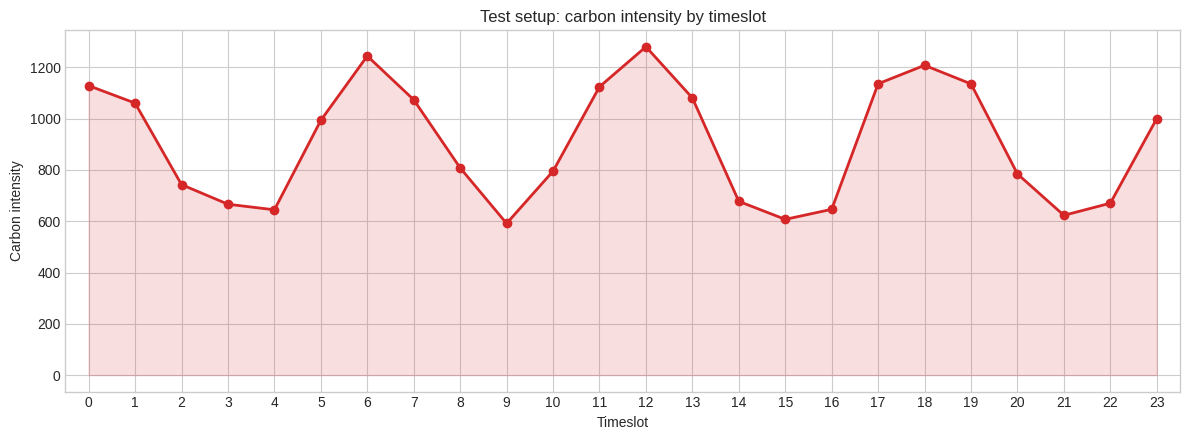

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
slots = list(range(total_slots))
carbon = scenario["carbon_forecast"]
ax.plot(slots, carbon, marker="o", linewidth=2.0, color="tab:red")
ax.fill_between(slots, carbon, alpha=0.15, color="tab:red")
ax.set_xlabel("Timeslot")
ax.set_ylabel("Carbon intensity")
ax.set_title("Test setup: carbon intensity by timeslot")
ax.set_xticks(slots)
ax.set_xlim(-0.5, total_slots - 0.5)
plt.tight_layout()

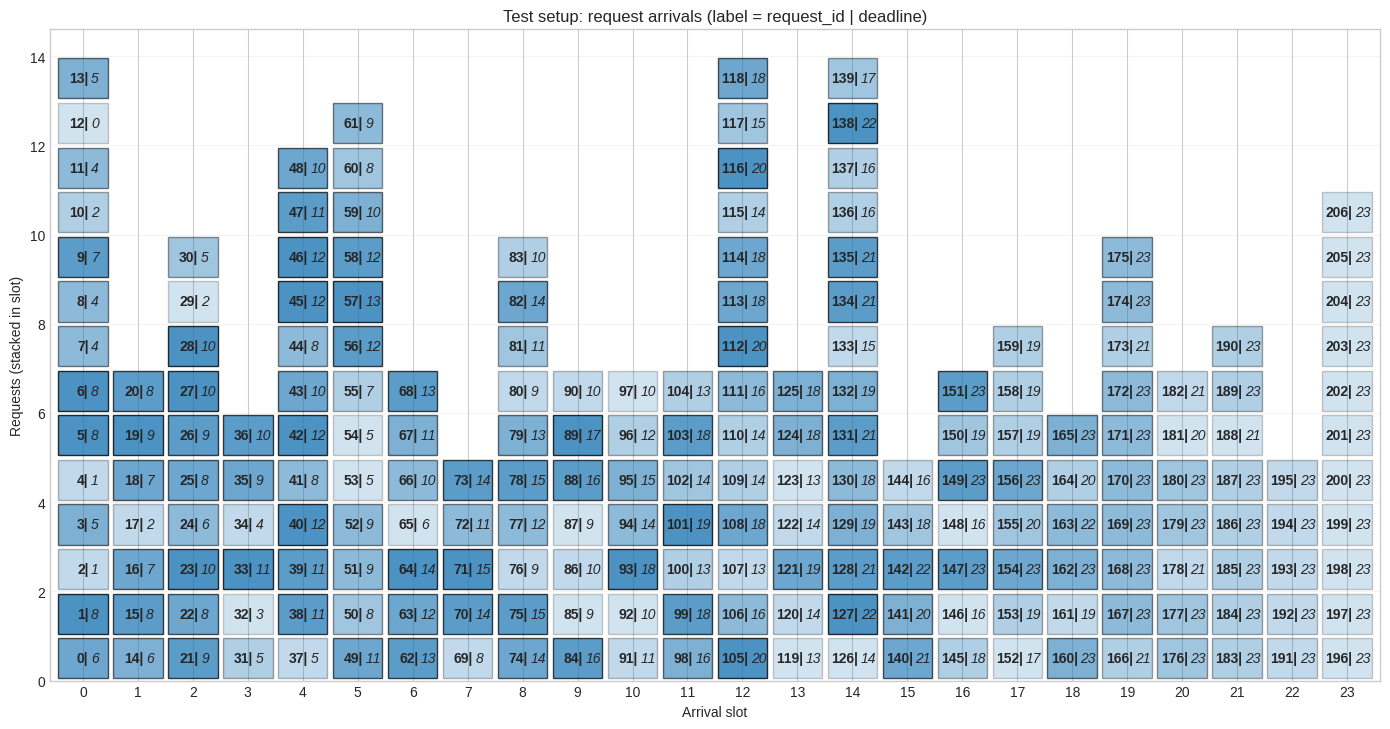

In [6]:
req_df = pd.DataFrame(scenario["requests"]).sort_values(["arrival_slot", "request_id"]).reset_index(drop=True)
grouped = defaultdict(list)
for row in req_df.to_dict(orient="records"):
    grouped[int(row["arrival_slot"])].append(row)

max_stack = max(len(v) for v in grouped.values()) if grouped else 1
fig_h = max(6, min(12, 1.1 + 0.45 * max_stack))
fig, ax = plt.subplots(figsize=(14, fig_h))

for slot in range(total_slots):
    arrivals = grouped.get(slot, [])
    for idx, req in enumerate(arrivals):
        y = idx
        slack = int(req["deadline_slot"]) - int(req["arrival_slot"])
        alpha = 0.2 + 0.6 * (slack / max(1, scenario["metadata"]["deadline_max_slack"]))
        rect = Rectangle((slot - 0.45, y + 0.05), 0.9, 0.9, facecolor="tab:blue", edgecolor="black", alpha=alpha)
        ax.add_patch(rect)
        
        ax.text(slot + 0.1, y + 0.5,f"{int(req['request_id'])}|",ha="right", va="center",fontsize=10,fontweight="bold")
        ax.text(slot + 0.15, y + 0.5,f"{int(req['deadline_slot'])}",ha="left", va="center",fontsize=10,style="italic")


ax.set_xlim(-0.6, total_slots - 0.4)
ax.set_ylim(0, max_stack + 0.6)
ax.set_xticks(list(range(total_slots)))
ax.set_xlabel("Arrival slot")
ax.set_ylabel("Requests (stacked in slot)")
ax.set_title("Test setup: request arrivals (label = request_id | deadline)")
ax.grid(True, axis="y", alpha=0.2)
plt.tight_layout()

## 2) Confronto metriche aggregate per N

In [7]:
display_cols = [
    "batch_size",
    "requests_total",
    "batches_executed",
    "solver_time_ms_avg",
    "queue_wait_seconds_avg",
    "final_wait_seconds_avg",
    "total_carbon_cost",
    "global_average_error",
]
summary_df[display_cols].round(4)

,batch_size,requests_total,batches_executed,solver_time_ms_avg,queue_wait_seconds_avg,final_wait_seconds_avg,total_carbon_cost,global_average_error
0,1,207,207,0.6859,0.0000,26.2326,5.363953e+06,3.9710
1,2,207,104,1.3048,0.5314,26.2332,5.002956e+06,4.0676
2,3,207,69,8.8651,1.2560,27.2069,6.224790e+06,4.0870
3,4,207,52,67.8812,1.5942,26.4933,5.026858e+06,4.1232
4,5,207,42,59.0862,2.1256,27.0164,7.157445e+06,4.0217
5,6,207,35,94.6781,2.5604,27.6806,6.250657e+06,3.9227
6,8,207,26,163.7124,4.2995,27.6041,6.834566e+06,3.8213
7,10,207,21,228.6683,4.7826,28.1547,7.487508e+06,3.7923


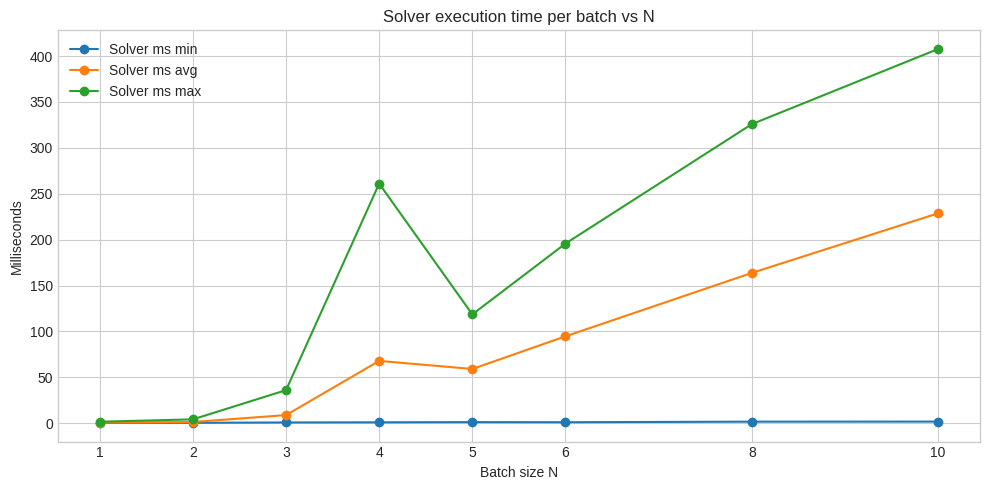

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
x = summary_df["batch_size"].astype(int)
ax.plot(x, summary_df["solver_time_ms_min"], marker="o", label="Solver ms min")
ax.plot(x, summary_df["solver_time_ms_avg"], marker="o", label="Solver ms avg")
ax.plot(x, summary_df["solver_time_ms_max"], marker="o", label="Solver ms max")
ax.set_xlabel("Batch size N")
ax.set_ylabel("Milliseconds")
ax.set_title("Solver execution time per batch vs N")
ax.set_xticks(x.tolist())
ax.legend()
plt.tight_layout()

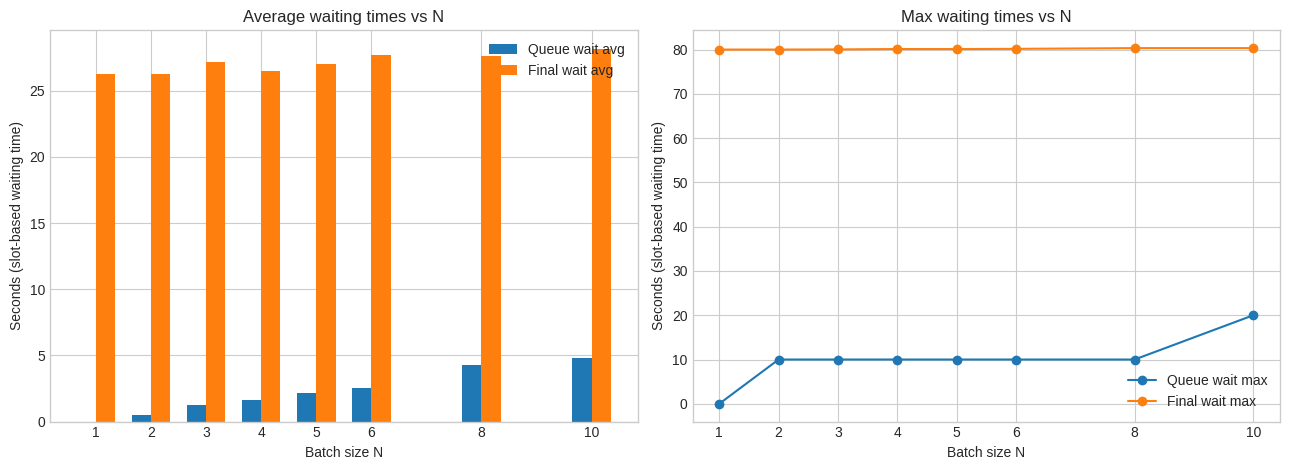

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = summary_df["batch_size"].astype(int)

width = 0.35
axes[0].bar(x - width / 2, summary_df["queue_wait_seconds_avg"], width=width, label="Queue wait avg")
axes[0].bar(x + width / 2, summary_df["final_wait_seconds_avg"], width=width, label="Final wait avg")
axes[0].set_xlabel("Batch size N")
axes[0].set_ylabel("Seconds (slot-based waiting time)")
axes[0].set_title("Average waiting times vs N")
axes[0].set_xticks(x.tolist())
axes[0].legend()

axes[1].plot(x, summary_df["queue_wait_seconds_max"], marker="o", label="Queue wait max")
axes[1].plot(x, summary_df["final_wait_seconds_max"], marker="o", label="Final wait max")
axes[1].set_xlabel("Batch size N")
axes[1].set_ylabel("Seconds (slot-based waiting time)")
axes[1].set_title("Max waiting times vs N")
axes[1].set_xticks(x.tolist())
axes[1].legend()

plt.tight_layout()

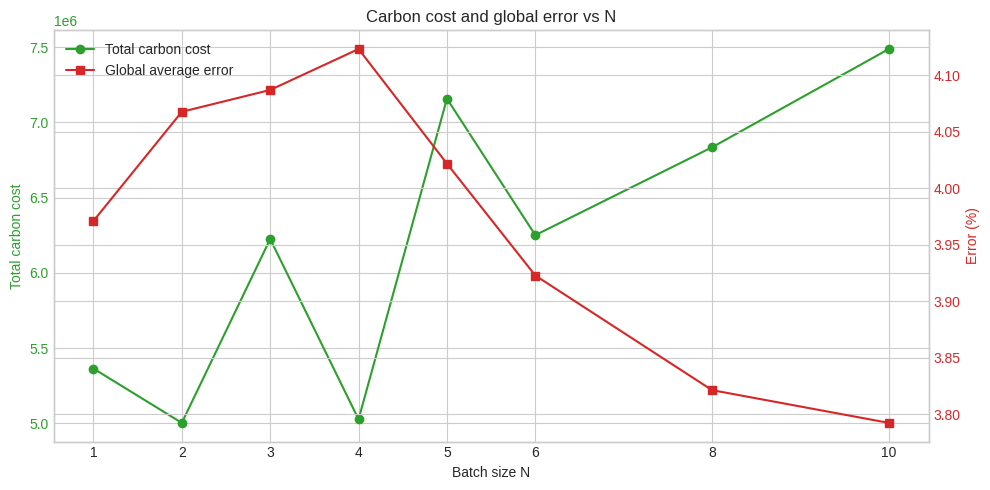

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))
x = summary_df["batch_size"].astype(int)

ax1.plot(x, summary_df["total_carbon_cost"], marker="o", color="tab:green", label="Total carbon cost")
ax1.set_xlabel("Batch size N")
ax1.set_ylabel("Total carbon cost", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")
ax1.set_xticks(x.tolist())

ax2 = ax1.twinx()
ax2.plot(x, summary_df["global_average_error"], marker="s", color="tab:red", label="Global average error")
ax2.set_ylabel("Error (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
ax1.set_title("Carbon cost and global error vs N")
plt.tight_layout()

## 3) Errori su window e distribuzioni dettagliate

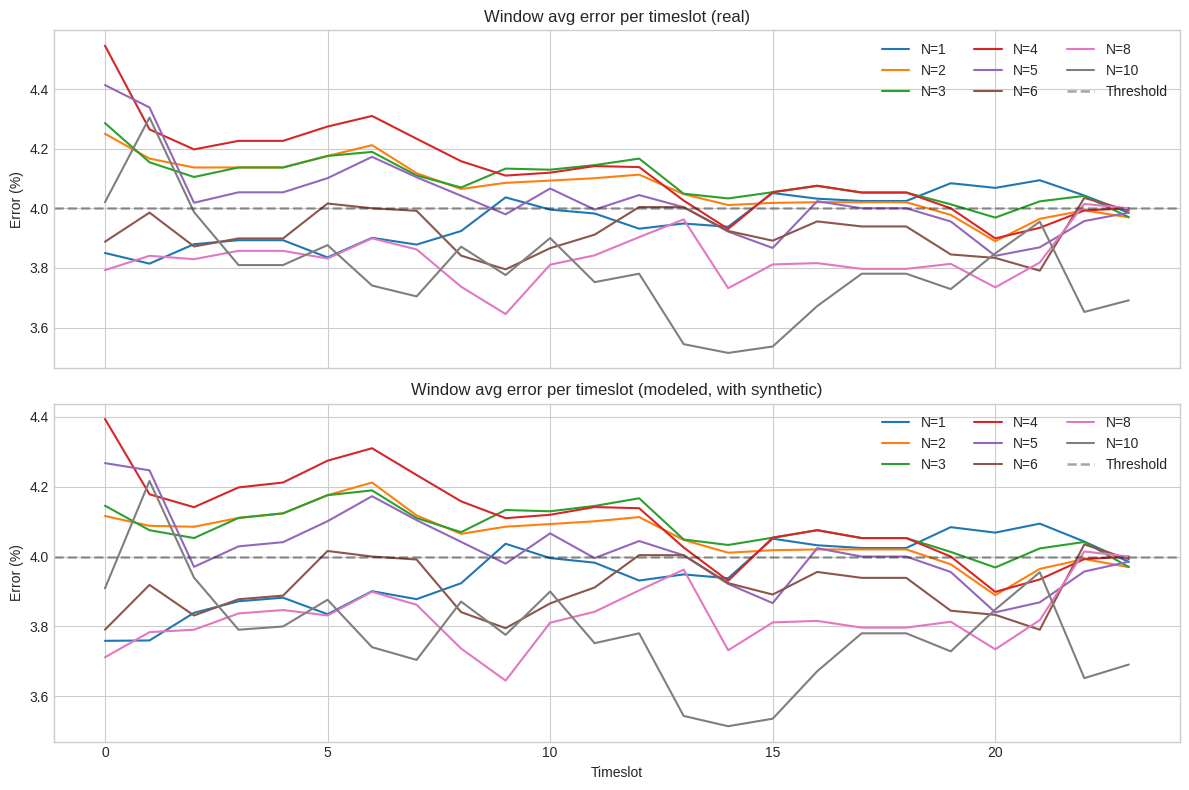

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for n, df in per_timeslot_by_n.items():
    data = df.sort_values("timeslot")
    axes[0].plot(data["timeslot"], data["window_avg_error_real"], label=f"N={n}")
    axes[1].plot(data["timeslot"], data["window_avg_error_modeled"], label=f"N={n}")

axes[0].axhline(threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.35, label="Threshold")
axes[1].axhline(threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.35, label="Threshold")

axes[0].set_ylabel("Error (%)")
axes[0].set_title("Window avg error per timeslot (real)")
axes[0].legend(ncol=3)

axes[1].set_xlabel("Timeslot")
axes[1].set_ylabel("Error (%)")
axes[1].set_title("Window avg error per timeslot (modeled, with synthetic)")
axes[1].legend(ncol=3)

plt.tight_layout()

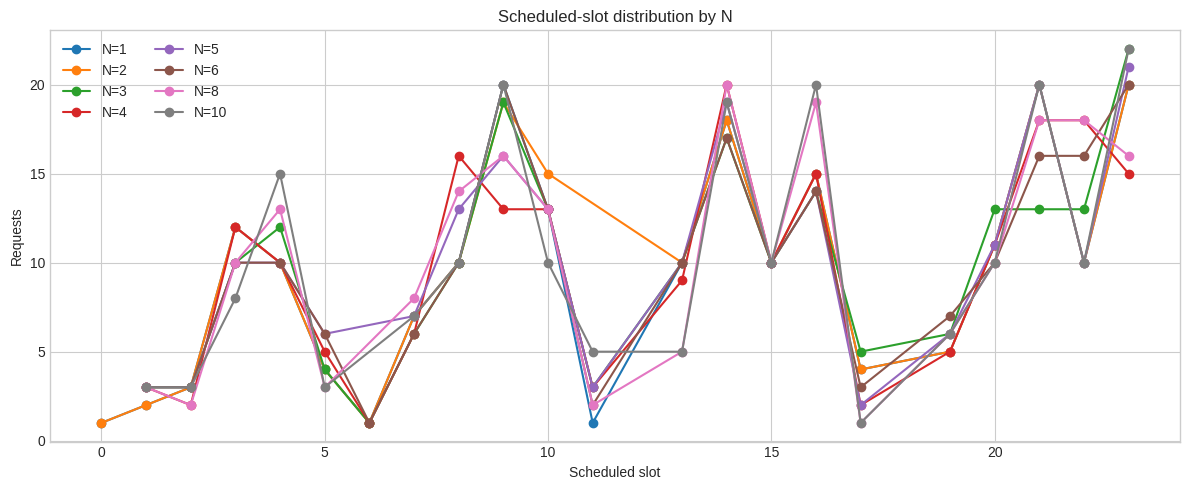

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

for n, df in per_request_by_n.items():
    local = df.copy()
    local["scheduled_slot"] = pd.to_numeric(local["scheduled_slot"], errors="coerce")
    counts = local.dropna(subset=["scheduled_slot"]).groupby("scheduled_slot").size().sort_index()
    ax.plot(counts.index.astype(int), counts.values, marker="o", label=f"N={n}")

ax.set_xlabel("Scheduled slot")
ax.set_ylabel("Requests")
ax.set_title("Scheduled-slot distribution by N")
ax.legend(ncol=2)
plt.tight_layout()

/tmp/ipykernel_58364/2681538569.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


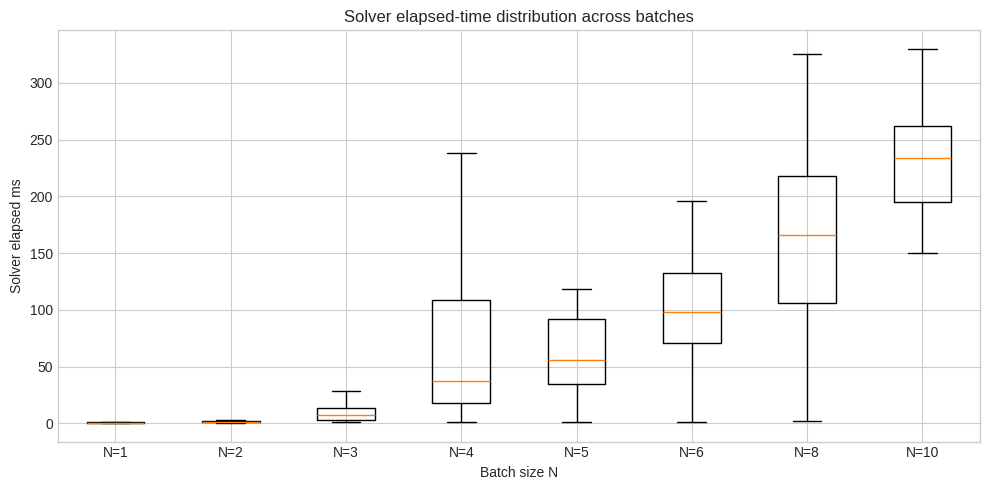

In [13]:
labels = []
data = []
for n, df in batch_timings_by_n.items():
    local = df.copy()
    local = local[local["scheduled"].astype(str).str.lower() == "true"]
    values = pd.to_numeric(local["solver_elapsed_ms"], errors="coerce").dropna().tolist()
    if values:
        labels.append(f"N={int(n)}")
        data.append(values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=labels, showfliers=False)
ax.set_xlabel("Batch size N")
ax.set_ylabel("Solver elapsed ms")
ax.set_title("Solver elapsed-time distribution across batches")
plt.tight_layout()